In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, least_squares
from scipy.ndimage import gaussian_filter1d
from scipy.integrate import simpson
from scipy.interpolate import PchipInterpolator

In [63]:
from pathlib import Path
# Original input file
input_file = "W118.csv"
# Read the original file
df = pd.read_csv(input_file)
# Extract the filename without ".csv"
input_path = Path(input_file)
base_name = input_path.stem
#fwhm, area, peak, position
# Use first two columns: Binding Energy and Intensity
x_original = df.iloc[:, 0].to_numpy(dtype=float)
y_original = df.iloc[:, 1].to_numpy(dtype=float)

## GENERATE SHIRLEY BACKGROUND

In [64]:
def auto_shirley_window(
    x,
    y,
    smooth_fraction=0.04,
    threshold_fraction=0.015,
    pad_fraction=0.06,
):
    """
    Propose a Shirley window around the detected peak envelope.

    The returned endpoints should be inspected manually before
    quantitative analysis.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    n = len(y_sorted)

    window = max(5, int(round(n * smooth_fraction)))

    if window % 2 == 0:
        window += 1

    largest_odd_window = n if n % 2 == 1 else n - 1
    window = min(window, largest_odd_window)

    half_window = window // 2
    kernel = np.ones(window, dtype=float) / window

    # Avoid zero-padding artifacts at the two data boundaries.
    y_padded = np.pad(
        y_sorted,
        pad_width=half_window,
        mode="edge"
    )

    y_smooth = np.convolve(
        y_padded,
        kernel,
        mode="valid"
    )

    edge_points = max(3, int(round(n * 0.08)))

    y_lowBE = np.median(y_smooth[:edge_points])
    y_highBE = np.median(y_smooth[-edge_points:])

    rough_baseline = np.linspace(
        y_lowBE,
        y_highBE,
        n
    )

    residual = y_smooth - rough_baseline
    positive_residual = np.maximum(residual, 0.0)

    residual_max = np.max(positive_residual)

    if residual_max <= 0:
        return float(x_sorted[0]), float(x_sorted[-1])

    active = np.flatnonzero(
        positive_residual
        > threshold_fraction * residual_max
    )

    if len(active) == 0:
        peak_index = int(np.argmax(positive_residual))
        active = np.array([peak_index])

    pad_points = max(2, int(round(n * pad_fraction)))

    left = max(0, active[0] - pad_points)
    right = min(n - 1, active[-1] + pad_points)

    return float(x_sorted[left]), float(x_sorted[right])

In [65]:
def shirley_background(
    x,
    y,
    fit_min=None,
    fit_max=None,
    endpoint_points=5,
    max_iter=500,
    rtol=1e-8,
    atol=1e-6,
):
    """
    Calculate a classic iterative Shirley background over a limited
    near-peak XPS energy range.

    Parameters
    ----------
    x : array-like
        Binding energy values.
    y : array-like
        Intensity values, preferably corrected for analyzer transmission.
    fit_min, fit_max : float, optional
        Binding-energy limits of the Shirley region.
    endpoint_points : int
        Number of points used to estimate each endpoint intensity.
    max_iter : int
        Maximum number of Shirley iterations.
    rtol, atol : float
        Relative and absolute convergence tolerances.

    Returns
    -------
    background : ndarray
        Shirley background in the original data order. Values outside
        the selected range are NaN.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.ndim != 1 or y.ndim != 1:
        raise ValueError("x and y must be one-dimensional arrays.")

    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    if len(x) < 3:
        raise ValueError("At least three data points are required.")

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise ValueError("x and y must contain only finite values.")

    # Sort from low binding energy to high binding energy.
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    # Duplicate energy values make integration ambiguous.
    if np.any(np.diff(x_sorted) <= 0):
        raise ValueError("Binding-energy values must be unique.")

    if fit_min is None:
        fit_min = float(x_sorted[0])

    if fit_max is None:
        fit_max = float(x_sorted[-1])

    fit_min, fit_max = sorted((float(fit_min), float(fit_max)))

    fit_mask = (x_sorted >= fit_min) & (x_sorted <= fit_max)

    if np.count_nonzero(fit_mask) < 3:
        raise ValueError(
            "The Shirley fit range must contain at least three points."
        )

    x_fit = x_sorted[fit_mask]
    y_fit = y_sorted[fit_mask]

    n_endpoint = min(
        int(endpoint_points),
        max(1, len(y_fit) // 4)
    )

    # Median endpoint levels reduce sensitivity to individual noisy points.
    y_lowBE = float(np.median(y_fit[:n_endpoint]))
    y_highBE = float(np.median(y_fit[-n_endpoint:]))

    # Initial approximation.
    bg = np.full_like(y_fit, y_lowBE, dtype=float)

    converged = False

    for iteration in range(1, max_iter + 1):
        bg_old = bg.copy()

        # Do not clip negative values; retain the iterative Shirley equation.
        net = y_fit - bg_old

        # Cumulative trapezoidal integral from low BE to high BE.
        dx = np.diff(x_fit)
        trapezoids = 0.5 * (net[:-1] + net[1:]) * dx

        cumulative_area = np.concatenate(
            ([0.0], np.cumsum(trapezoids))
        )

        total_area = cumulative_area[-1]

        if (
            not np.isfinite(total_area)
            or abs(total_area) < np.finfo(float).eps
        ):
            raise RuntimeError(
                "The net Shirley area is zero or non-finite. "
                "Check the selected endpoints."
            )

        bg = (
            y_lowBE
            + (y_highBE - y_lowBE)
            * cumulative_area
            / total_area
        )

        if np.allclose(bg, bg_old, rtol=rtol, atol=atol):
            converged = True
            print(f"Converged after {iteration} iterations")
            break

    if not converged:
        raise RuntimeError(
            f"Shirley background did not converge after "
            f"{max_iter} iterations."
        )

    bg_sorted = np.full(y_sorted.shape, np.nan, dtype=float)
    bg_sorted[fit_mask] = bg

    background = np.empty_like(bg_sorted)
    background[order] = bg_sorted

    return background

In [66]:
# Only divide by transmission if Count/s has not already been corrected.
y_for_analysis = y_original
# y_for_analysis = count_per_second / transmission

SHIRLEY_MIN_BE, SHIRLEY_MAX_BE = auto_shirley_window(
    x_original,
    y_for_analysis
)

print(
    f"Proposed Shirley window: "
    f"{SHIRLEY_MIN_BE:.2f} to {SHIRLEY_MAX_BE:.2f} eV"
)

shirley = shirley_background(
    x_original,
    y_for_analysis,
    fit_min=SHIRLEY_MIN_BE,
    fit_max=SHIRLEY_MAX_BE,
    endpoint_points=5
)

corrected = y_for_analysis - shirley

Proposed Shirley window: 200.48 to 213.18 eV
Converged after 7 iterations


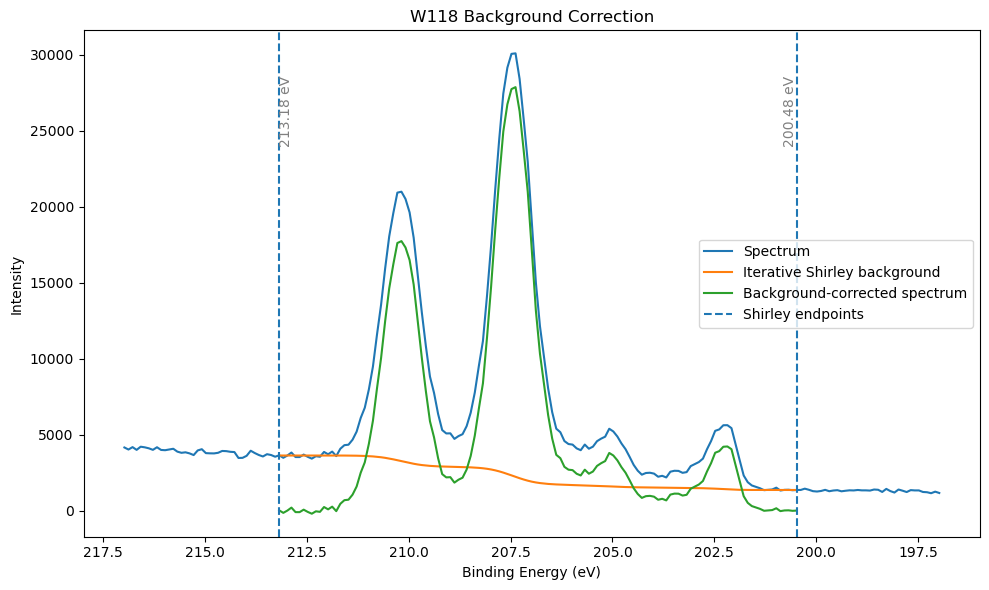

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    x_original,
    y_for_analysis,
    label="Spectrum"
)

plt.plot(
    x_original,
    shirley,
    label="Iterative Shirley background"
)

plt.plot(
    x_original,
    corrected,
    label="Background-corrected spectrum"
)

plt.axvline(
    SHIRLEY_MIN_BE,
    linestyle="--",
    label="Shirley endpoints"
)

plt.axvline(
    SHIRLEY_MAX_BE,
    linestyle="--"
)

y_top = np.max(y_original)

plt.text(SHIRLEY_MIN_BE, y_top * 0.95, f"{SHIRLEY_MIN_BE:.2f} eV",
         rotation=90, va="top", ha="right", fontsize=10, color="gray")

plt.text(SHIRLEY_MAX_BE, y_top * 0.95, f"{SHIRLEY_MAX_BE:.2f} eV",
         rotation=90, va="top", ha="left", fontsize=10, color="gray")
plt.title(f"{base_name} Background Correction")
plt.xlabel("Binding Energy (eV)")
plt.ylabel("Intensity")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

# Revised fitting pipeline

This version preserves the requested sequence:

1. **Shirley background**
2. **Simultaneous fitting**
3. **Binding-energy shift**

Changes made to improve area stability without applying area-calibration ratios:

- Uses area fractions estimated from the seven reference datasets only as the first starting guess.
- Generates independent randomized area distributions for the remaining multi-start fits.
- Fits one shared oxide FWHM for NbO, NbO2, and Nb2O5.
- Fits one shared oxide pseudo-Voigt eta for NbO, NbO2, and Nb2O5.
- Keeps the original post-background intensity shift.
- Applies the energy shift only after fitting so metallic Nb 3d5/2 is exactly 202.200 eV.


In [68]:
# ============================================================
# PREPARE THE BACKGROUND-CORRECTED DATA
# Retains the original baseline-shifting process.
# ============================================================

x = np.asarray(x_original, dtype=float)
y = np.asarray(corrected, dtype=float)

mask = (
    (x >= SHIRLEY_MIN_BE)
    & (x <= SHIRLEY_MAX_BE)
    & np.isfinite(x)
    & np.isfinite(y)
)

x = x[mask]
y = y[mask]

order = np.argsort(x)
x = x[order]
y = y[order]

# Retain the user's original shifting of the corrected intensity baseline.
intensity_shift = -float(np.min(y))
y = y + intensity_shift

print(f"Fitting window: {x.min():.3f} to {x.max():.3f} eV")
print(f"Applied corrected-intensity shift: {intensity_shift:+.6f}")
print(f"Shifted corrected minimum: {np.min(y):.6f}")

Fitting window: 200.480 to 213.180 eV
Applied corrected-intensity shift: +205.890395
Shifted corrected minimum: 0.000000


In [69]:
# ============================================================
# PHYSICAL CONSTANTS AND LINE SHAPES
# ============================================================

SPLIT = 2.72
RATIO = 2.0 / 3.0

# Preserve the metallic-Nb internal-width calibration from the original notebook.
METAL_FWHM_CALIBRATION = np.mean([
    0.81600 / 1.72100,
    0.63663 / 1.34900,
    0.60000 / 1.28700,
    0.58000 / 1.25200,
    0.59000 / 1.25600,
    0.55000 / 1.12500,
    0.57000 / 1.22500,
])

def metal_internal_to_fwhm(internal_width):
    return float(internal_width) * METAL_FWHM_CALIBRATION

def metal_fwhm_to_internal(fwhm):
    return float(fwhm) / METAL_FWHM_CALIBRATION

def pseudo_voigt(x_values, height, center, fwhm, eta):
    sigma = fwhm / 2.354820045
    gaussian = np.exp(-0.5 * ((x_values - center) / sigma) ** 2)
    lorentzian = 1.0 / (1.0 + 4.0 * ((x_values - center) / fwhm) ** 2)
    return height * ((1.0 - eta) * gaussian + eta * lorentzian)

def oxide_doublet_height(x_values, height, center_5_2, shared_fwhm, eta):
    p_5_2 = pseudo_voigt(
        x_values, height, center_5_2, shared_fwhm, eta
    )
    p_3_2 = pseudo_voigt(
        x_values,
        height * RATIO,
        center_5_2 + SPLIT,
        shared_fwhm,
        eta,
    )
    return p_5_2 + p_3_2

def LA_peak(x_values, height, center, internal_width,
            alpha=1.2, beta=5.0, m=12.0):
    gamma = internal_width / 2.0
    lorentz = 1.0 / (1.0 + ((x_values - center) / gamma) ** 2)

    profile = np.zeros_like(x_values, dtype=float)
    low_be = x_values <= center
    profile[low_be] = lorentz[low_be] ** beta
    profile[~low_be] = lorentz[~low_be] ** alpha

    if m > 0:
        profile = gaussian_filter1d(profile, sigma=m / 10.0)

    maximum = np.max(profile)
    if not np.isfinite(maximum) or maximum <= 0:
        return np.zeros_like(x_values, dtype=float)

    return height * profile / maximum

def metal_doublet_height(x_values, height, center_5_2, internal_width):
    p_5_2 = LA_peak(
        x_values, height, center_5_2, internal_width
    )
    p_3_2 = LA_peak(
        x_values,
        height * RATIO,
        center_5_2 + SPLIT,
        internal_width,
    )
    return p_5_2 + p_3_2

print(f"Metal FWHM calibration factor = {METAL_FWHM_CALIBRATION:.6f}")

Metal FWHM calibration factor = 0.471353


In [70]:
# ============================================================
# AREA-NORMALIZED COMPONENTS
#
# The fitted area is defined as the component area inside the
# selected Shirley/fitting window. Normalization is recalculated
# whenever position, width, or line shape changes.
# ============================================================

def window_normalize(x_values, unit_curve):
    area = float(simpson(unit_curve, x=x_values))
    if not np.isfinite(area) or abs(area) < 1e-15:
        return np.zeros_like(unit_curve)
    return unit_curve / abs(area)

def metal_component(x_values, area, center_5_2, internal_width):
    unit_curve = metal_doublet_height(
        x_values, 1.0, center_5_2, internal_width
    )
    return area * window_normalize(x_values, unit_curve)

def oxide_component(
    x_values,
    area,
    center_5_2,
    shared_oxide_fwhm,
    eta,
):
    unit_curve = oxide_doublet_height(
        x_values,
        1.0,
        center_5_2,
        shared_oxide_fwhm,
        eta,
    )
    return area * window_normalize(x_values, unit_curve)

In [71]:
# ============================================================
# SIMULTANEOUS MODEL
#
# Parameters:
#  0  Nb metal area
#  1  Nb metal 3d5/2 position
#  2  Nb metal internal LA width
#  3  shared oxide FWHM
#  4  shared oxide eta
#  5  NbO area
#  6  NbO 3d5/2 position
#  7  NbO2 area
#  8  NbO2 3d5/2 position
#  9  Nb2O5 area
# 10  Nb2O5 3d5/2 position
# ============================================================

def component_curves(x_values, p):
    shared_oxide_fwhm = p[3]
    shared_oxide_eta = p[4]

    metal = metal_component(
        x_values,
        area=p[0],
        center_5_2=p[1],
        internal_width=p[2],
    )

    nbo = oxide_component(
        x_values,
        area=p[5],
        center_5_2=p[6],
        shared_oxide_fwhm=shared_oxide_fwhm,
        eta=shared_oxide_eta,
    )

    nbo2 = oxide_component(
        x_values,
        area=p[7],
        center_5_2=p[8],
        shared_oxide_fwhm=shared_oxide_fwhm,
        eta=shared_oxide_eta,
    )

    nb2o5 = oxide_component(
        x_values,
        area=p[9],
        center_5_2=p[10],
        shared_oxide_fwhm=shared_oxide_fwhm,
        eta=shared_oxide_eta,
    )

    return metal, nbo, nbo2, nb2o5


def total_model(x_values, p):
    return np.sum(component_curves(x_values, p), axis=0)


In [72]:
# ============================================================
# STARTING VALUES AND PHYSICAL BOUNDS
# ============================================================

def pchip_integral(x_values, y_values, x_min=None, x_max=None):
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)

    valid = np.isfinite(x_values) & np.isfinite(y_values)
    x_values = x_values[valid]
    y_values = y_values[valid]

    order = np.argsort(x_values)
    x_values = x_values[order]
    y_values = y_values[order]

    x_values, unique_idx = np.unique(x_values, return_index=True)
    y_values = y_values[unique_idx]

    if x_min is None:
        x_min = x_values[0]
    if x_max is None:
        x_max = x_values[-1]

    x_min, x_max = sorted((float(x_min), float(x_max)))
    spline = PchipInterpolator(x_values, y_values, extrapolate=False)
    anti = spline.antiderivative()
    return float(abs(anti(x_max) - anti(x_min)))


total_area_guess = max(pchip_integral(x, y), 1.0)

CENTER_TARGETS = {
    "metal": 202.20,
    "nbo": 204.30,
    "nbo2": 206.12,
    "nb2o5": 207.70,
}

# These bounds are left unchanged so this version tests the effects of
# improved initialization and shared oxide line shape without forcing
# the fitted peak positions.
CENTER_HALF_WIDTHS = {
    "metal": 0.30,
    "nbo": 0.65,
    "nbo2": 0.45,
    "nb2o5": 0.45,
}

metal_fwhm_guess = 0.75
metal_internal_guess = metal_fwhm_to_internal(metal_fwhm_guess)

shared_oxide_fwhm_guess = 1.12
shared_oxide_eta_guess = 0.30

# Representative composition from the seven supplied reference datasets.
# These values are starting guesses only; they are not final constraints.
initial_fractions = np.array([
    0.14454,  # Nb metal
    0.02357,  # NbO
    0.03829,  # NbO2
    0.79360,  # Nb2O5
], dtype=float)

# Protect against accidental rounding changes.
initial_fractions = initial_fractions / initial_fractions.sum()
initial_areas = total_area_guess * initial_fractions

labels = ["Nb metal", "NbO", "NbO2", "Nb2O5"]

print("\nINITIAL AREA GUESSES\n")
for label, fraction, area in zip(labels, initial_fractions, initial_areas):
    print(f"{label:<8} fraction = {fraction:.5f}, area = {area:.2f}")

# Parameter vector:
# [metal area, metal center, metal internal width,
#  shared oxide FWHM, shared oxide eta,
#  NbO area, NbO center,
#  NbO2 area, NbO2 center,
#  Nb2O5 area, Nb2O5 center]
p0 = np.array([
    initial_areas[0],
    CENTER_TARGETS["metal"],
    metal_internal_guess,

    shared_oxide_fwhm_guess,
    shared_oxide_eta_guess,

    initial_areas[1],
    CENTER_TARGETS["nbo"],

    initial_areas[2],
    CENTER_TARGETS["nbo2"],

    initial_areas[3],
    CENTER_TARGETS["nb2o5"],
], dtype=float)

lower = np.array([
    0.0,
    CENTER_TARGETS["metal"] - CENTER_HALF_WIDTHS["metal"],
    metal_fwhm_to_internal(0.35),

    0.85,
    0.0,

    0.0,
    CENTER_TARGETS["nbo"] - CENTER_HALF_WIDTHS["nbo"],

    0.0,
    CENTER_TARGETS["nbo2"] - CENTER_HALF_WIDTHS["nbo2"],

    0.0,
    CENTER_TARGETS["nb2o5"] - CENTER_HALF_WIDTHS["nb2o5"],
], dtype=float)

upper = np.array([
    2.0 * total_area_guess,
    CENTER_TARGETS["metal"] + CENTER_HALF_WIDTHS["metal"],
    metal_fwhm_to_internal(1.20),

    1.40,
    1.0,

    2.0 * total_area_guess,
    CENTER_TARGETS["nbo"] + CENTER_HALF_WIDTHS["nbo"],

    2.0 * total_area_guess,
    CENTER_TARGETS["nbo2"] + CENTER_HALF_WIDTHS["nbo2"],

    2.0 * total_area_guess,
    CENTER_TARGETS["nb2o5"] + CENTER_HALF_WIDTHS["nb2o5"],
], dtype=float)

print(f"\nInitial total area: {total_area_guess:.2f}")
print(f"Initial shared oxide FWHM: {shared_oxide_fwhm_guess:.3f} eV")
print(f"Initial shared oxide eta: {shared_oxide_eta_guess:.3f}")



INITIAL AREA GUESSES

Nb metal fraction = 0.14454, area = 9958.51
NbO      fraction = 0.02357, area = 1623.92
NbO2     fraction = 0.03829, area = 2638.10
Nb2O5    fraction = 0.79360, area = 54677.40

Initial total area: 68897.94
Initial shared oxide FWHM: 1.120 eV
Initial shared oxide eta: 0.300


In [73]:
# ============================================================
# MULTI-START SIMULTANEOUS FIT
# ============================================================

# Because y has already been shifted after Shirley subtraction,
# ordinary least squares is retained.
sigma = np.ones_like(y)

def residual_vector(p):
    return (total_model(x, p) - y) / sigma


rng = np.random.default_rng(42)
starts = [p0.copy()]

# Parameter locations in the revised vector.
AREA_INDICES = (0, 5, 7, 9)
CONTINUOUS_INDICES = (1, 2, 3, 4, 6, 8, 10)

# The concentration parameters favor plausible oxide-dominated starts,
# while still producing genuinely different positive compositions.
dirichlet_alpha = np.array([3.0, 1.0, 1.0, 8.0])

for _ in range(99):
    trial = p0.copy()

    # Draw four positive fractions that sum exactly to one.
    random_fractions = rng.dirichlet(dirichlet_alpha)
    random_areas = total_area_guess * random_fractions

    for idx, area in zip(AREA_INDICES, random_areas):
        trial[idx] = area

    # Independently vary positions, widths, and the shared eta.
    for idx in CONTINUOUS_INDICES:
        span = upper[idx] - lower[idx]
        trial[idx] += rng.normal(0.0, 0.12 * span)

    trial = np.clip(trial, lower + 1e-10, upper - 1e-10)
    starts.append(trial)


candidates = []

for start_number, start in enumerate(starts):
    try:
        result = least_squares(
            residual_vector,
            start,
            bounds=(lower, upper),
            method="trf",
            x_scale="jac",
            loss="linear",
            max_nfev=100000,
            ftol=1e-11,
            xtol=1e-11,
            gtol=1e-11,
        )

        if result.success and np.all(np.isfinite(result.x)):
            score = float(np.mean(residual_vector(result.x) ** 2))
            candidates.append((score, start_number, result))

    except (ValueError, RuntimeError, FloatingPointError):
        pass


if not candidates:
    raise RuntimeError("All simultaneous fitting starts failed.")

candidates.sort(key=lambda item: item[0])
best_score, best_start_number, best_result = candidates[0]
popt = best_result.x

print(f"Successful starts: {len(candidates)} / {len(starts)}")
print(f"Best starting trial: {best_start_number}")
print(f"Best mean squared residual: {best_score:.8g}")

# Show whether several starts converged to similarly good solutions.
print("\nFive best mean squared residuals:")
for rank, (score, start_number, _) in enumerate(candidates[:5], start=1):
    print(f"{rank}: score = {score:.8g}, start = {start_number}")


Successful starts: 100 / 100
Best starting trial: 67
Best mean squared residual: 49049.249

Five best mean squared residuals:
1: score = 49049.249, start = 67
2: score = 49049.249, start = 16
3: score = 49049.249, start = 92
4: score = 49049.249, start = 18
5: score = 49049.249, start = 49


In [74]:
# ============================================================
# UNSHIFTED SIMULTANEOUS RESULTS
# ============================================================

component_names = ["Nb metal", "NbO", "NbO2", "Nb2O5"]
area_indices = [0, 5, 7, 9]
center_indices = [1, 6, 8, 10]

fitted_areas = np.array([popt[i] for i in area_indices])
unshifted_centers = np.array([popt[i] for i in center_indices])

metal_fwhm_reported = metal_internal_to_fwhm(popt[2])
shared_oxide_fwhm = popt[3]
shared_oxide_eta = popt[4]

print(f"\n{base_name} UNSHIFTED SIMULTANEOUS RESULTS\n")

print(
    f"Nb metal: Area = {popt[0]:.2f}, "
    f"3d5/2 = {popt[1]:.3f} eV, "
    f"FWHM = {metal_fwhm_reported:.3f} eV"
)
print(
    f"NbO     : Area = {popt[5]:.2f}, "
    f"3d5/2 = {popt[6]:.3f} eV, "
    f"FWHM = {shared_oxide_fwhm:.3f} eV"
)
print(
    f"NbO2    : Area = {popt[7]:.2f}, "
    f"3d5/2 = {popt[8]:.3f} eV, "
    f"FWHM = {shared_oxide_fwhm:.3f} eV"
)
print(
    f"Nb2O5   : Area = {popt[9]:.2f}, "
    f"3d5/2 = {popt[10]:.3f} eV, "
    f"FWHM = {shared_oxide_fwhm:.3f} eV"
)

print(f"\nTotal fitted area = {fitted_areas.sum():.2f}")
print(f"Shared oxide eta = {shared_oxide_eta:.4f}")
print("All oxides share one fitted FWHM and one fitted eta.")
print("Doublet separation = 2.72 eV")
print("3d5/2 : 3d3/2 area ratio = 3 : 2")



W118 UNSHIFTED SIMULTANEOUS RESULTS

Nb metal: Area = 8878.62, 3d5/2 = 202.186 eV, FWHM = 0.625 eV
NbO     : Area = 1620.73, 3d5/2 = 204.290 eV, FWHM = 1.091 eV
NbO2    : Area = 2711.97, 3d5/2 = 205.993 eV, FWHM = 1.091 eV
Nb2O5   : Area = 55449.15, 3d5/2 = 207.457 eV, FWHM = 1.091 eV

Total fitted area = 68660.46
Shared oxide eta = 0.1130
All oxides share one fitted FWHM and one fitted eta.
Doublet separation = 2.72 eV
3d5/2 : 3d3/2 area ratio = 3 : 2


# Binding-energy shift

The simultaneous fit is completed first. Then the same shift used in the original
notebook is applied:

```python
shift = 202.200 - fitted_metal_position
```

The same constant is added to every species position and to the plotted energy axis.

In [75]:
# ============================================================
# APPLY THE ORIGINAL ENERGY-SHIFT PROCESS AFTER FITTING
# ============================================================

REFERENCE_METAL_BE = 202.200
energy_shift = REFERENCE_METAL_BE - popt[1]

shifted_centers = unshifted_centers + energy_shift
x_shifted = x + energy_shift

metal_shifted, nbo_shifted, nbo2_shifted, nb2o5_shifted = shifted_centers

print(f"\n{base_name} SHIFTED BINDING ENERGIES\n")

print(
    f"Nb metal 3d5/2: {metal_shifted:.3f} eV, "
    f"FWHM = {metal_fwhm_reported:.3f} eV"
)
print(
    f"NbO      3d5/2: {nbo_shifted:.3f} eV, "
    f"FWHM = {shared_oxide_fwhm:.3f} eV"
)
print(
    f"NbO2     3d5/2: {nbo2_shifted:.3f} eV, "
    f"FWHM = {shared_oxide_fwhm:.3f} eV"
)
print(
    f"Nb2O5    3d5/2: {nb2o5_shifted:.3f} eV, "
    f"FWHM = {shared_oxide_fwhm:.3f} eV"
)

print(f"\nApplied energy shift = {energy_shift:+.3f} eV")


W118 SHIFTED BINDING ENERGIES

Nb metal 3d5/2: 202.200 eV, FWHM = 0.625 eV
NbO      3d5/2: 204.304 eV, FWHM = 1.091 eV
NbO2     3d5/2: 206.006 eV, FWHM = 1.091 eV
Nb2O5    3d5/2: 207.471 eV, FWHM = 1.091 eV

Applied energy shift = +0.014 eV


In [76]:
# ============================================================
# SPLINE AREA VERIFICATION
# ============================================================

x_dense = np.linspace(x.min(), x.max(), 6000)
dense_components = component_curves(x_dense, popt)
dense_total = np.sum(dense_components, axis=0)

spline_areas = np.array([
    pchip_integral(x_dense, curve, x.min(), x.max())
    for curve in dense_components
])

area_table = pd.DataFrame({
    "Component": component_names,
    "Direct fitted area": fitted_areas,
    "PCHIP verification area": spline_areas,
    "Difference": spline_areas - fitted_areas,
    "Unshifted 3d5/2 (eV)": unshifted_centers,
    "Shifted 3d5/2 (eV)": shifted_centers,
    "FWHM (eV)": [
        metal_fwhm_reported,
        shared_oxide_fwhm,
        shared_oxide_fwhm,
        shared_oxide_fwhm,
    ],
    "Eta": [
        np.nan,
        shared_oxide_eta,
        shared_oxide_eta,
        shared_oxide_eta,
    ],
})

display(area_table)

print(f"\nExperimental corrected area = {pchip_integral(x, y):.2f}")
print(f"Sum of direct fitted areas  = {fitted_areas.sum():.2f}")
print(f"Sum of PCHIP areas          = {spline_areas.sum():.2f}")


,Component,Direct fitted area,PCHIP verification area,Difference,Unshifted 3d5/2 (eV),Shifted 3d5/2 (eV),FWHM (eV),Eta
0,Nb metal,8878.616546,8878.616546,-6.376104e-08,202.186127,202.200000,0.625025,NaN
1,NbO,1620.732970,1620.732970,1.887202e-11,204.289700,204.303572,1.091346,0.113001
2,NbO2,2711.966089,2711.966089,-1.091394e-11,205.992585,206.006457,1.091346,0.113001
3,Nb2O5,55449.145634,55449.145634,2.910383e-11,207.457225,207.471098,1.091346,0.113001



Experimental corrected area = 68897.94
Sum of direct fitted areas  = 68660.46
Sum of PCHIP areas          = 68660.46


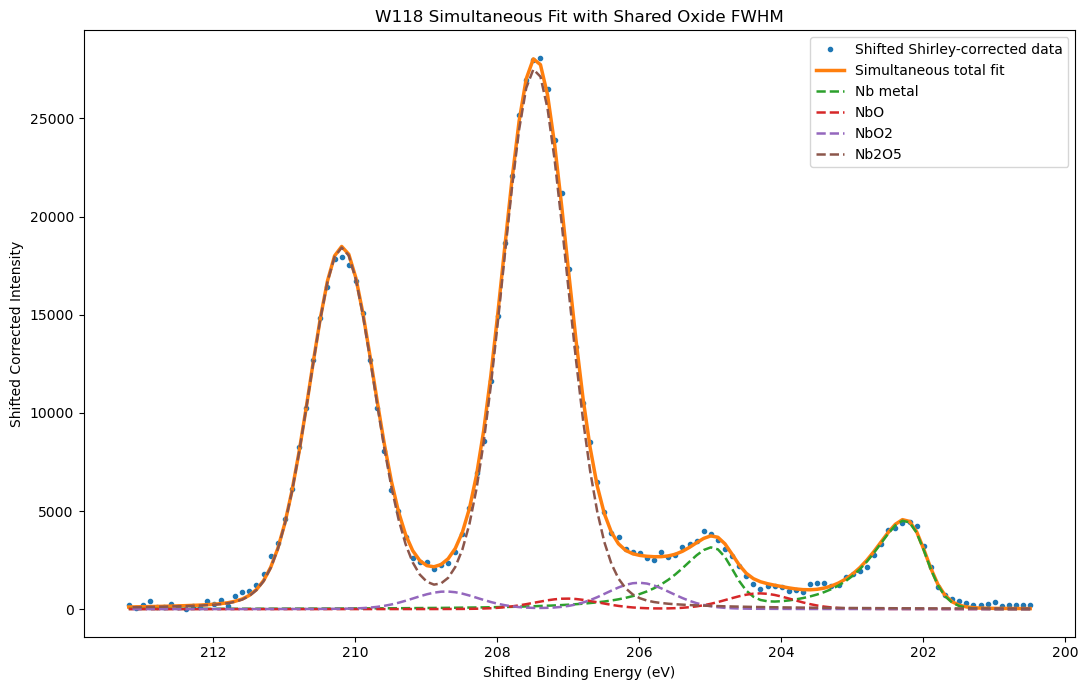

In [77]:
# ============================================================
# SHIFTED FIT PLOT
# ============================================================

# Evaluate the fit on the original unshifted coordinate grid,
# then shift the x-axis after fitting.
model_at_x = total_model(x, popt)
components_at_x = component_curves(x, popt)

plt.figure(figsize=(11, 7))

plt.plot(
    x_shifted,
    y,
    "o",
    markersize=3,
    label="Shifted Shirley-corrected data",
)
plt.plot(
    x_shifted,
    model_at_x,
    linewidth=2.5,
    label="Simultaneous total fit",
)

for name, curve in zip(component_names, components_at_x):
    plt.plot(
        x_shifted,
        curve,
        "--",
        linewidth=1.8,
        label=name,
    )

plt.xlabel("Shifted Binding Energy (eV)")
plt.ylabel("Shifted Corrected Intensity")
plt.title(f"{base_name} Simultaneous Fit with Shared Oxide FWHM")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

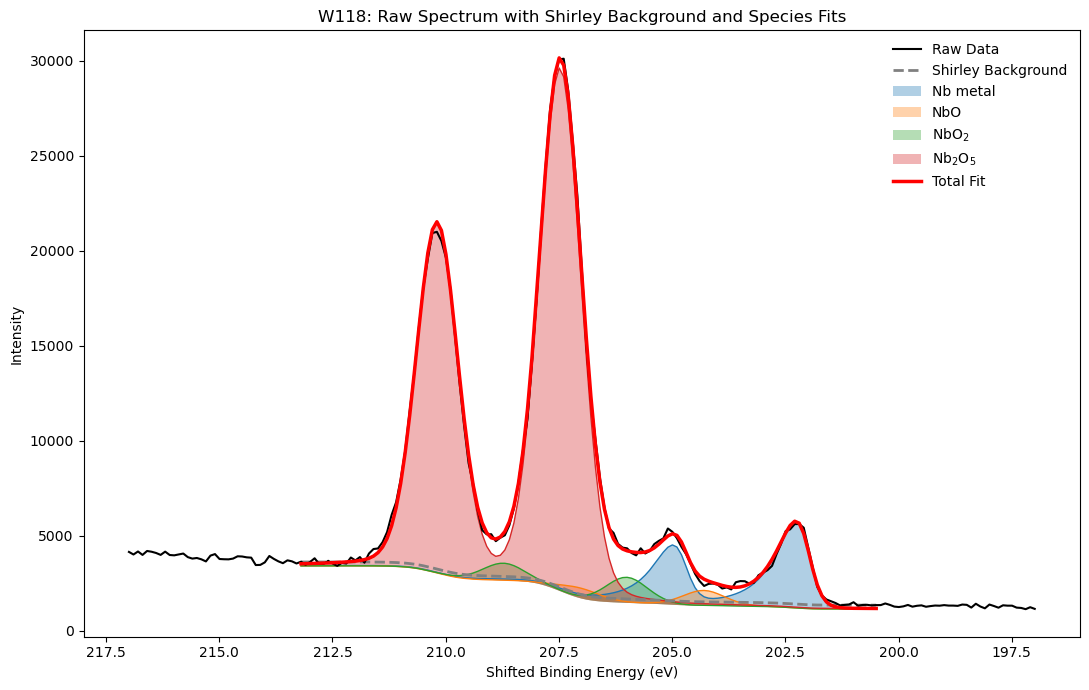

In [81]:
# ============================================================
# RAW DATA + SHIRLEY BACKGROUND + INDIVIDUAL SPECIES FITS
# ============================================================

valid_bg = np.isfinite(shirley)
bg_order = np.argsort(x_original[valid_bg])

# Shirley background evaluated on fitting grid
shirley_at_x = np.interp(
    x,
    x_original[valid_bg][bg_order],
    shirley[valid_bg][bg_order],
)

# Shift original spectrum
raw_x_shifted = x_original + energy_shift

# ------------------------------------------------------------
# Individual fitted components (background subtracted)
# ------------------------------------------------------------

nb_metal, nbo, nbo2, nb2o5 = component_curves(x, popt)

# Add Shirley background back
nb_metal_bg = nb_metal + shirley_at_x - intensity_shift
nbo_bg      = nbo      + shirley_at_x - intensity_shift
nbo2_bg     = nbo2     + shirley_at_x - intensity_shift
nb2o5_bg    = nb2o5    + shirley_at_x - intensity_shift

total_fit_bg = model_at_x + shirley_at_x - intensity_shift

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(11,7))

# Raw spectrum
plt.plot(
    raw_x_shifted,
    y_original,
    color='black',
    lw=1.5,
    label='Raw Data',
    zorder=10
)

# Shirley background
plt.plot(
    raw_x_shifted,
    shirley,
    '--',
    color='gray',
    lw=2,
    label='Shirley Background',
    zorder=3
)

# Filled species
plt.fill_between(
    x_shifted,
    shirley_at_x - intensity_shift,
    nb_metal_bg,
    alpha=0.35,
    label='Nb metal'
)

plt.fill_between(
    x_shifted,
    shirley_at_x - intensity_shift,
    nbo_bg,
    alpha=0.35,
    label='NbO'
)

plt.fill_between(
    x_shifted,
    shirley_at_x - intensity_shift,
    nbo2_bg,
    alpha=0.35,
    label=r'NbO$_2$'
)

plt.fill_between(
    x_shifted,
    shirley_at_x - intensity_shift,
    nb2o5_bg,
    alpha=0.35,
    label=r'Nb$_2$O$_5$'
)

# Optional outlines
plt.plot(x_shifted, nb_metal_bg, lw=1)
plt.plot(x_shifted, nbo_bg, lw=1)
plt.plot(x_shifted, nbo2_bg, lw=1)
plt.plot(x_shifted, nb2o5_bg, lw=1)

# Total fit
plt.plot(
    x_shifted,
    total_fit_bg,
    color='red',
    lw=2.5,
    label='Total Fit',
    zorder=20
)

plt.xlabel("Shifted Binding Energy (eV)")
plt.ylabel("Intensity")
plt.title(f"{base_name}: Raw Spectrum with Shirley Background and Species Fits")

plt.gca().invert_xaxis()
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

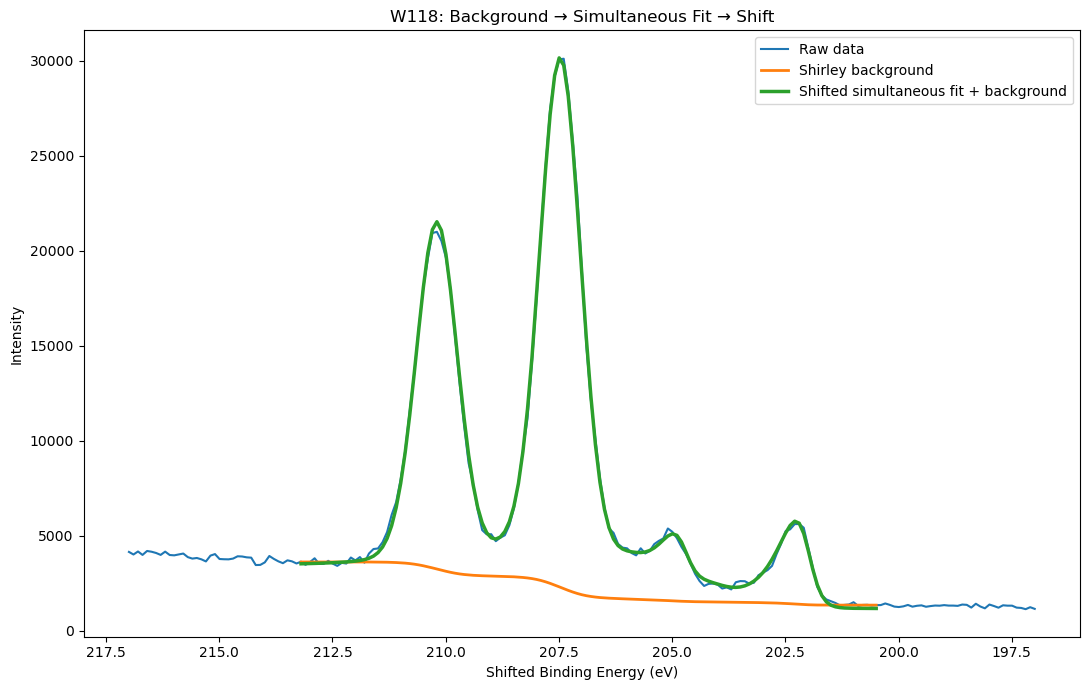

In [ ]:
# ============================================================
# RAW DATA, SHIRLEY BACKGROUND, AND SHIFTED FIT
# ============================================================

valid_bg = np.isfinite(shirley)
bg_order = np.argsort(x_original[valid_bg])

shirley_at_x = np.interp(
    x,
    x_original[valid_bg][bg_order],
    shirley[valid_bg][bg_order],
)

raw_x_shifted = x_original + energy_shift
shirley_x_shifted = x_original + energy_shift

plt.figure(figsize=(11, 7))

plt.plot(
    raw_x_shifted,
    y_original,
    label="Raw data",
)
plt.plot(
    shirley_x_shifted,
    shirley,
    label="Shirley background",
    linewidth=2,
)
plt.plot(
    x_shifted,
    model_at_x + shirley_at_x - intensity_shift,
    label="Shifted simultaneous fit + background",
    linewidth=2.5,
)

plt.xlabel("Shifted Binding Energy (eV)")
plt.ylabel("Intensity")
plt.title(f"{base_name}: Background → Simultaneous Fit → Shift")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

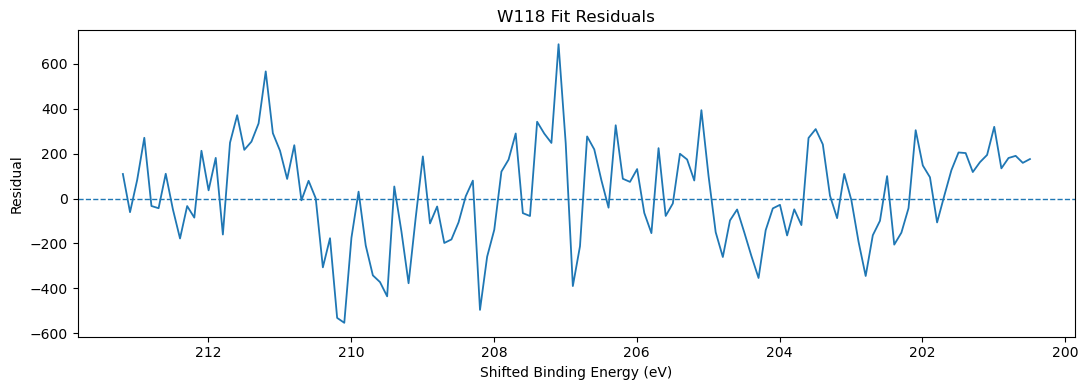

,Component,Area,Area 1-sigma,Shifted position (eV),Position 1-sigma (eV),FWHM (eV),FWHM 1-sigma (eV),Eta,Eta 1-sigma
0,Nb metal,8878.616546,241.847668,202.200000,0.010289,0.625025,0.024862,NaN,NaN
1,NbO,1620.732970,183.548981,204.303572,0.074079,1.091346,0.005184,0.113001,0.018508
2,NbO2,2711.966089,238.441333,206.006457,0.047685,1.091346,0.005184,0.113001,0.018508
3,Nb2O5,55449.145634,364.564040,207.471098,0.002074,1.091346,0.005184,0.113001,0.018508


Residual standard deviation = 220.574083


In [ ]:
# ============================================================
# RESIDUALS AND APPROXIMATE UNCERTAINTIES
# ============================================================

residuals = y - total_model(x, popt)

plt.figure(figsize=(11, 4))
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.plot(x_shifted, residuals, linewidth=1.3)
plt.xlabel("Shifted Binding Energy (eV)")
plt.ylabel("Residual")
plt.title(f"{base_name} Fit Residuals")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

jacobian = best_result.jac
degrees_of_freedom = max(len(y) - len(popt), 1)

try:
    covariance = np.linalg.pinv(jacobian.T @ jacobian)
    covariance *= 2.0 * best_result.cost / degrees_of_freedom
    parameter_std = np.sqrt(np.clip(np.diag(covariance), 0.0, None))
except np.linalg.LinAlgError:
    parameter_std = np.full_like(popt, np.nan)

metal_fwhm_std = parameter_std[2] * METAL_FWHM_CALIBRATION
shared_oxide_fwhm_std = parameter_std[3]
shared_oxide_eta_std = parameter_std[4]

uncertainty_table = pd.DataFrame({
    "Component": component_names,
    "Area": fitted_areas,
    "Area 1-sigma": parameter_std[area_indices],
    "Shifted position (eV)": shifted_centers,
    "Position 1-sigma (eV)": parameter_std[center_indices],
    "FWHM (eV)": [
        metal_fwhm_reported,
        shared_oxide_fwhm,
        shared_oxide_fwhm,
        shared_oxide_fwhm,
    ],
    "FWHM 1-sigma (eV)": [
        metal_fwhm_std,
        shared_oxide_fwhm_std,
        shared_oxide_fwhm_std,
        shared_oxide_fwhm_std,
    ],
    "Eta": [
        np.nan,
        shared_oxide_eta,
        shared_oxide_eta,
        shared_oxide_eta,
    ],
    "Eta 1-sigma": [
        np.nan,
        shared_oxide_eta_std,
        shared_oxide_eta_std,
        shared_oxide_eta_std,
    ],
})

display(uncertainty_table)

print(f"Residual standard deviation = {np.std(residuals):.6f}")


In [ ]:
# ============================================================
# MULTI-START STABILITY DIAGNOSTIC
# ============================================================

top_n = min(10, len(candidates))
top_solutions = np.array([
    candidates[i][2].x[area_indices]
    for i in range(top_n)
])

stability_table = pd.DataFrame({
    "Component": component_names,
    "Best-fit area": fitted_areas,
    f"Mean area across best {top_n} starts": np.mean(top_solutions, axis=0),
    f"Std. dev. across best {top_n} starts": np.std(top_solutions, axis=0),
})

display(stability_table)

print(
    "Large variation across similarly good starts indicates that the "
    "overlapping components are not uniquely determined by the current model."
)


,Component,Best-fit area,Mean area across best 10 starts,Std. dev. across best 10 starts
0,Nb metal,8878.616546,8878.616570,0.000137
1,NbO,1620.732970,1620.732920,0.000052
2,NbO2,2711.966089,2711.966116,0.000031
3,Nb2O5,55449.145634,55449.145604,0.000165


Large variation across similarly good starts indicates that the overlapping components are not uniquely determined by the current model.


In [ ]:
# ============================================================
# RAW AREA UNDER EACH FINAL FITTED COMPONENT
#
# This cell does not change the fit.
# It only evaluates the already-fitted curves and integrates them.
# No area calibration, reference ratio, or correction factor is used.
# ============================================================

from scipy.integrate import simpson

x_area = np.linspace(np.min(x), np.max(x), 20000)

metal_curve, nbo_curve, nbo2_curve, nb2o5_curve = component_curves(
    x_area,
    popt,
)

raw_areas = np.array([
    abs(simpson(metal_curve, x=x_area)),
    abs(simpson(nbo_curve, x=x_area)),
    abs(simpson(nbo2_curve, x=x_area)),
    abs(simpson(nb2o5_curve, x=x_area)),
])

raw_area_table = pd.DataFrame({
    "Component": ["Nb metal", "NbO", "NbO2", "Nb2O5"],
    "Raw integrated area": raw_areas,
})

display(raw_area_table)

print("\nRAW AREA UNDER EACH FITTED CURVE\n")
print(f"Nb metal = {raw_areas[0]:.2f}")
print(f"NbO      = {raw_areas[1]:.2f}")
print(f"NbO2     = {raw_areas[2]:.2f}")
print(f"Nb2O5    = {raw_areas[3]:.2f}")
print("--------------------------------")
print(f"Sum      = {raw_areas.sum():.2f}")


,Component,Raw integrated area
0,Nb metal,8878.616546
1,NbO,1620.732970
2,NbO2,2711.966089
3,Nb2O5,55449.145634



RAW AREA UNDER EACH FITTED CURVE

Nb metal = 8878.62
NbO      = 1620.73
NbO2     = 2711.97
Nb2O5    = 55449.15
--------------------------------
Sum      = 68660.46
